# Flux reconciliation for the ECOMICS experimental reaction fluxes

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
import pandas as pd
from typing import Dict, List, Tuple, Optional
import warnings
import os
import sys
import cobra
from cobra.io import load_model

# Add paths
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../scripts'))

# Add directories
data_dir = "../data"

# Optimization Problem

**Data:**

- **MEAS** - indices of reactions with measured fluxes
- **INPUTS** - reactions with fixed fluxes (e.g. media components)
- $\bar{v}_j$ - measured reaction flux
- $S$ - stoichiometric matrix
- $d$ - vector of weights for each of the reaction rates in the inner LP (FBA)
- $v_L, v_U$ - lower / upper bounds on reaction rates

**Variables:**

- $v$ - reconciled reaction-flux vector
- $\lambda$ - dual multipliers for the mass-balance constraints
- $\alpha^L, \alpha^U$ - duals for lower/upper bounds



**Minimize:**
$$\min_{v, \lambda, \alpha^L, \alpha^U} \sum_{j \in MEAS} \left(\frac{v_j - \bar{v}_j}{\bar{v}_j}\right)^2$$

**Subject to:**

$$S v = 0 \quad \text{(steady-state mass balance)}$$

$$d + S_{int}^T \lambda + \alpha^L - \alpha^U = 0 \quad \text{(dual feasibility constraint)}$$

$$v_j = \bar{v}_j, \quad j \in \text{INPUTS} \quad \text{(fixed uptakes)}$$

$$v_L \leq v \leq v_U \quad \text{(flux bounds)}$$

$$(v_j - v_{L,j}) \alpha_j^L = 0, \quad (v_{U,j} - v_j) \alpha_j^U = 0, \quad j = 1, \ldots, n \quad \text{(complimentary constraints)}$$

$$\alpha^L \geq 0, \quad \alpha^U \geq 0 \quad \text{(non-negativity of dual variables)}$$

# Small network

In [2]:
# Network: Glucose_ext --(uptake)--> Glucose_int --(glycolysis)--> Pyruvate_int
#                                                                      |
#                                                         |------------|------------|
#                                                         v                         v
#                                                   Lactate_ext                Biomass

### 1. Model Inputs


In [3]:
# S matrix 

# Columns: reactions
#   1. Glucose_uptake
#   2. Pyr_formation
#   3. Lactate_formation
#   4. Biomass_formation

# Rows: metabolites 
#   1. Glucose_internal
#   2. Pyruvate_internal

S = np.array([
    [ 1, -1,  0,  0],  # Glucose_internal: +1 from uptake, -1 to pyruvate formation
    [ 0,  1, -1, -1],  # Pyruvate_internal: +1 from glucose, -1 to lactate, -1 to biomass  
])

metabolite_names = ['Glucose_internal', 'Pyruvate_internal']
reaction_names = ['Glucose_uptake', 'Pyr_formation', 'Lactate_formation', 'Biomass_formation']

n_metabolites = len(metabolite_names)
n_reactions = len(reaction_names)

# Reaction fluxes
# Note: all fluxes should be positive for forward reactions
# The S matrix handles the directionality (consumption vs production)
measurements = {
    'Glucose_uptake': -10,      # Positive: rate of glucose consumption
    'Pyr_formation': 10,       # Should equal glucose uptake due to mass balance
    'Lactate_formation': 9,    # Part of pyruvate goes to lactate
    'Biomass_formation': 7     # Part of pyruvate goes to biomass
}

# Fixed fluxes
fixed_fluxes = {
    'Glucose_uptake': 10.0  # Fix glucose uptake rate
}

# Flux bounds - all reactions are forward (positive)
flux_bounds = {
    'Glucose_uptake': (0, 20),    # Forward only (glucose consumption)
    'Pyr_formation': (0, 20),     # Forward only
    'Lactate_formation': (0, 15), # Forward only
    'Biomass_formation': (0, 10)  # Forward only
}

### 2. Check mass balance consistency

Mass balance constraints from S matrix:
1. Glucose_internal: v_glucose_uptake - v_pyr_formation = 0
   => v_glucose_uptake = v_pyr_formation
2. Pyruvate_internal: v_pyr_formation - v_lactate_formation - v_biomass_formation = 0
   => v_pyr_formation = v_lactate_formation + v_biomass_formation

In [4]:
# Check mass balance consistency of measurements
print("Current measurements:")
for reaction, flux in measurements.items():
    print(f"  {reaction}: {flux}")

# Check constraints
glucose_uptake = measurements['Glucose_uptake']
pyr_formation = measurements['Pyr_formation'] 
lactate_formation = measurements['Lactate_formation']
biomass_formation = measurements['Biomass_formation']

print(f"\nConstraint 1 check:")
print(f"  Glucose uptake: {glucose_uptake}")
print(f"  Pyruvate formation: {pyr_formation}")
print(f"  Difference: {abs(glucose_uptake - pyr_formation)}")

print(f"\nConstraint 2 check:")
print(f"  Pyruvate formation: {pyr_formation}")
print(f"  Lactate + Biomass: {lactate_formation + biomass_formation}")
print(f"  Difference: {abs(pyr_formation - (lactate_formation + biomass_formation))}")


Current measurements:
  Glucose_uptake: -10
  Pyr_formation: 10
  Lactate_formation: 9
  Biomass_formation: 7

Constraint 1 check:
  Glucose uptake: -10
  Pyruvate formation: 10
  Difference: 20

Constraint 2 check:
  Pyruvate formation: 10
  Lactate + Biomass: 16
  Difference: 6


### 3. Set the fluxes bounds

In [5]:
# Set flux bounds
bounds = {}

# Default bounds
default_lower = -1000.0
default_upper = 1000.0

for i, reaction_name in enumerate(reaction_names):
    if flux_bounds and reaction_name in flux_bounds:
        bounds[i] = flux_bounds[reaction_name]
    else:
        bounds[i] = (default_lower, default_upper)

### 4. Setting up the flux reconciliation model

In [6]:
# Initialize Pyomo model
model = pyo.ConcreteModel()
        
# Sets
model.metabolites = pyo.Set(initialize=range(n_metabolites))
model.reactions = pyo.Set(initialize=range(n_reactions))
model.measured_reactions = pyo.Set(initialize=[
    j for j, name in enumerate(reaction_names)
    if name in measurements 
])

# Variables
# Reaction fluxes
model.v = pyo.Var(model.reactions, bounds=(-1000, 1000))

# Dual variables for optimiality conditions
model.alpha_L = pyo.Var(model.reactions, bounds=(0, 1000))    # Lower bound multipliers
model.alpha_U = pyo.Var(model.reactions, bounds=(0, 1000))    # Upper bound multipliers

# Apply flux bounds to reaction variables
for i in model.reactions:
    model.v[i].setlb(bounds[i][0])
    model.v[i].setub(bounds[i][1])
    
# Fixed fluxes 
if fixed_fluxes:
    for reaction_name, flux_value in fixed_fluxes.items():
        if reaction_name in reaction_names:
            reaction_idx = reaction_names.index(reaction_name)
            model.v[reaction_idx].fix(flux_value)

In [7]:
# Vector of initial weights (zeros). Each entry corresponds to a reaction
objective_weights = np.zeros(n_reactions)

# Assign weight of 1.0 to reaction of objective function
objective_reaction = 'Biomass_formation'
reaction_idx = reaction_names.index(objective_reaction)
objective_weights[reaction_idx] = 1.0

In [8]:
# Objective function: minimizing the deviation of estimated rates from measured rates
def objective_rule(m):
    return sum(
        ((m.v[j] - measurements[reaction_names[j]])/measurements[reaction_names[j]])**2
        for j in m.measured_reactions
    )
model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

# Mass balance constraints (S matrix)
def mass_balance_rule(m, i):
    return sum(S[i, j] * m.v[j] for j in m.reactions) == 0
model.mass_balance = pyo.Constraint(model.metabolites, rule=mass_balance_rule)


#### **NOTE:** Uncomment the next cell to include optimality constraints 

In [9]:
# Parameters
barrier_param = 1e-6

# Dual feasibility constraint
def stationarity_rule(m, j):
    return (objective_weights[j] + m.alpha_L[j] - m.alpha_U[j] == 0)
model.stationarity = pyo.Constraint(model.reactions, rule=stationarity_rule)
    
# Complementarity constraints
def comp_lower_rule(m, j):
    return (m.v[j] - bounds[j][0]) * m.alpha_L[j] <= barrier_param
model.comp_lower = pyo.Constraint(model.reactions, rule=comp_lower_rule)
        
def comp_upper_rule(m, j):
    return (bounds[j][1] - m.v[j]) * m.alpha_U[j] <= barrier_param
model.comp_upper = pyo.Constraint(model.reactions, rule=comp_upper_rule)


### 5. Solving the model

In [10]:
# Configure solver
solver_options = {
    'max_iter': 3000,
    'tol': 1e-8,
    'acceptable_tol': 1e-6,
}

solver = pyo.SolverFactory('ipopt')

for key, value in solver_options.items():
        solver.options[key] = value

# Solve
try:
    results = solver.solve(model, tee=True)
    
    if (results.solver.termination_condition == TerminationCondition.optimal or
        results.solver.termination_condition == TerminationCondition.locallyOptimal):
        
        # Extract results
        reconciled_fluxes = {
            reaction_names[j]: pyo.value(model.v[j])
            for j in model.reactions
        }
        
        objective_value = pyo.value(model.obj)
        
        results_dict = {
            'reconciled_reaction_fluxes': reconciled_fluxes,
            'objective_value': objective_value,
            'solver_status': 'optimal',
            'original_measurements': measurements,
        }
        
        print(f"Objective value: {objective_value}")
        
    else:
        print(f"Solver terminated with condition: {results.solver.termination_condition}")
        results_dict = {'solver_status': 'failed', 'termination_condition': str(results.solver.termination_condition)}
        
except Exception as e:
    print(f"Error during solving: {str(e)}")
    results_dict = {'solver_status': 'error', 'error_message': str(e)}

Ipopt 3.14.17: max_iter=3000
tol=1e-08
acceptable_tol=1e-06


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:       12
Number of nonzeros in inequality constraint Jacobian.:       14
Number of nonzeros in Lagrangian Hessian.............:        9

Total number of variables............................:       11
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       11
                     variables with only upper bounds:        0
Total number of equality constr

### TAKEAWAYS
When using the Optimality constraints the optimization results change significantly. The objective value is also much higher. Could this mean that the optimality constraints lead to worse results? (for this small network they do)

- Obj value without optimality constraints: 4.28
- Obj value with optimality constraints: 5.18

# ECOMICS fluxomics data

### 1. Prep the fluxomics data

In [11]:
# Load data
condition_string = 'W3110_MD121_M9+Glu_none'
exp_fluxes_path = os.path.join(data_dir, "processed", "ECOMICS", f"fluxomics_{condition_string}.csv")
exp_fluxes_df = pd.read_csv(exp_fluxes_path)

# Rename the rxn_id column
exp_fluxes_df.rename(columns={'exp_reaction': 'rxn_id'}, inplace=True)

# Remove the 'R000X_' prefix
exp_fluxes_df['rxn_id'] = exp_fluxes_df['rxn_id'].str.replace(r'^R\d+_', '', regex=True)

In [12]:
# Group by rxn_id and for multiple matches, take the first one (190 --> 145)
# TO DO: These should be manually checked with the output of ECOMICS_fluxomics.ipynb
exp_fluxes_df = exp_fluxes_df.groupby('rxn_id', as_index=False).agg({'exp_flux': 'first'})

In [13]:
# Divide by 10 because the glucose uptake rate will be set to 10 mmol/gDW/h
exp_fluxes_df.iloc[:, 1] = exp_fluxes_df.iloc[:, 1] / 10

In [14]:
# Remove 0 fluxes --> these are actually NaN values
exp_fluxes_df = exp_fluxes_df[exp_fluxes_df['exp_flux'] != 0]

### 2. Set the fixed fluxes (e.g. medium components)
TO DOs:
- Check if 'fixing' to an exact number works better than setting the upper/lower bounds
- Check if discarding some of these (e.g. co2, o2) would give better results

In [15]:
condition_string = 'W3110_MD121_M9+Glu_none'
fixed_fluxes_path = os.path.join(data_dir, "processed", "ECOMICS", f"medium_{condition_string}.csv")
fixed_fluxes_df = pd.read_csv(fixed_fluxes_path)

In [16]:
# Inspect the fixed fluxes dataframe
print(fixed_fluxes_df)

     rxn_id  exp_fixed_flux
0  EX_so4_e             1.7
1   EX_o2_e           158.6
2  EX_co2_e           175.2
3  EX_nh4_e            50.1


In [17]:
# Add a row for glucose uptake
new_row = pd.DataFrame([{'rxn_id': 'EX_glc__D_e', 'exp_fixed_flux': 100}])
fixed_fluxes_df = pd.concat([fixed_fluxes_df, new_row], ignore_index=True)

# Divide by 10 because the glucose uptake rate will be set to 10 mmol/gDW/h
fixed_fluxes_df.iloc[:, 1] = fixed_fluxes_df.iloc[:, 1] / 10

# Convert to negative values (they are uptakes)
fixed_fluxes_df.iloc[:, 1] = fixed_fluxes_df.iloc[:, 1] * -1

# Convert CO2 exchange to positive as it is a production
fixed_fluxes_df.loc[fixed_fluxes_df['rxn_id'] == 'EX_co2_e', 'exp_fixed_flux'] = fixed_fluxes_df.loc[fixed_fluxes_df['rxn_id'] == 'EX_co2_e', 'exp_fixed_flux'] * -1

print(fixed_fluxes_df)

        rxn_id  exp_fixed_flux
0     EX_so4_e           -0.17
1      EX_o2_e          -15.86
2     EX_co2_e           17.52
3     EX_nh4_e           -5.01
4  EX_glc__D_e          -10.00


In [18]:
# # Export to csv
# fixed_fluxes_df.to_csv(os.path.join(data_dir, f"fixed_fluxes_df.csv"), index=False)

In [19]:
# Minimal fixed fluxes using just EX_glc__D_e
minimal_fixed_fluxes = fixed_fluxes_df[fixed_fluxes_df['rxn_id'] == 'EX_glc__D_e'].copy()
print(minimal_fixed_fluxes)

        rxn_id  exp_fixed_flux
4  EX_glc__D_e           -10.0


# *E. coli* core model

In [20]:
# Load model
core_model_path = os.path.join(data_dir, "raw", "GEMs", "e_coli_core.xml")
core_model = cobra.io.read_sbml_model(core_model_path)

print(f'Number of reactions for core model: {len(core_model.reactions)}')

Number of reactions for core model: 95


In [21]:
# FBA check
core_model.optimize()
print(core_model.objective.value)

0.8739215069684302


In [22]:
for key, value in core_model.medium.items():
    print(f"{key}: {value}")

EX_co2_e: 1000.0
EX_glc__D_e: 10.0
EX_h_e: 1000.0
EX_h2o_e: 1000.0
EX_nh4_e: 1000.0
EX_o2_e: 1000.0
EX_pi_e: 1000.0


#### Using minimal fixed fluxes - just glucose uptake set to -10 $\frac{1}{h}$

In [23]:
from scripts.flux_reconciliation_module import flux_reconciliation

recon_minimal_core_results = flux_reconciliation(core_model_path, 
                              exp_fluxes_df, 
                              minimal_fixed_fluxes,
                              obj_rxn='BIOMASS_Ecoli_core_w_GAM',
                              solver_name='ipopt'
                              )

Model loaded successfully from ../data\raw\GEMs\e_coli_core.xml
Model contains 95 reactions and 72 metabolites

=== Model Information ===
Number of reactions: 95
Number of metabolites: 72
S matrix shape: (72, 95)
Number of non-zero elements in S: 360
Sample of flux bounds:
PFK: (0.0, 1000.0)
PFL: (0.0, 1000.0)
PGI: (-1000.0, 1000.0)
PGK: (-1000.0, 1000.0)
PGL: (0.0, 1000.0)

=== Validating Stoichiometric Matrix ===

=== Measured Fluxes Information ===
Total measured reactions: 128
Matched measurements: 33
Missing reactions: 95
First few missing reactions: ['ACHBS', 'ACLS', 'ACt2rpp', 'ACtex', 'ADSK']

Sample of measurements:
ACKr: flux = 6.590000000000001
ACONTa: flux = 1.72
ACONTb: flux = 1.72
AKGDH: flux = 1.3800000000000001
CS: flux = 2.5

=== Fixed Fluxes Information ===
Total fixed reactions: 1
Matched fixed fluxes: 1
Missing reactions: 0

All fixed fluxes:
EX_glc__D_e: -10.0

=== Validating Measurements Against Bounds ===

=== Optimization Model Setup ===
Sample of bounds:
PFK: (

c:\Users\lyachinas\OneDrive - University of Toronto\GitHub\CatNivoDataset\scripts\flux_reconciliation_module.py:113: UserWarning: Reaction ACHBS not found in model reactions
  warnings.warn(f"Reaction {rxn_id} not found in model reactions")
c:\Users\lyachinas\OneDrive - University of Toronto\GitHub\CatNivoDataset\scripts\flux_reconciliation_module.py:113: UserWarning: Reaction ACLS not found in model reactions
  warnings.warn(f"Reaction {rxn_id} not found in model reactions")
c:\Users\lyachinas\OneDrive - University of Toronto\GitHub\CatNivoDataset\scripts\flux_reconciliation_module.py:113: UserWarning: Reaction ACt2rpp not found in model reactions
  warnings.warn(f"Reaction {rxn_id} not found in model reactions")
c:\Users\lyachinas\OneDrive - University of Toronto\GitHub\CatNivoDataset\scripts\flux_reconciliation_module.py:113: UserWarning: Reaction ACtex not found in model reactions
  warnings.warn(f"Reaction {rxn_id} not found in model reactions")
c:\Users\lyachinas\OneDrive - Unive

#### Using all fixed fluxes

In [24]:
from scripts.flux_reconciliation_module import flux_reconciliation

recon_core_results = flux_reconciliation(core_model_path, 
                              exp_fluxes_df, 
                              fixed_fluxes_df,
                              obj_rxn='BIOMASS_Ecoli_core_w_GAM',
                              solver_name='ipopt'
                              )

Model loaded successfully from ../data\raw\GEMs\e_coli_core.xml
Model contains 95 reactions and 72 metabolites

=== Model Information ===
Number of reactions: 95
Number of metabolites: 72
S matrix shape: (72, 95)
Number of non-zero elements in S: 360
Sample of flux bounds:
PFK: (0.0, 1000.0)
PFL: (0.0, 1000.0)
PGI: (-1000.0, 1000.0)
PGK: (-1000.0, 1000.0)
PGL: (0.0, 1000.0)

=== Validating Stoichiometric Matrix ===

=== Measured Fluxes Information ===
Total measured reactions: 128
Matched measurements: 33
Missing reactions: 95
First few missing reactions: ['ACHBS', 'ACLS', 'ACt2rpp', 'ACtex', 'ADSK']

Sample of measurements:
ACKr: flux = 6.590000000000001
ACONTa: flux = 1.72
ACONTb: flux = 1.72
AKGDH: flux = 1.3800000000000001
CS: flux = 2.5

  Measured value: 5.01
  Fixed value: -5.01
Using fixed value and not measured value.

=== Fixed Fluxes Information ===
Total fixed reactions: 5
Matched fixed fluxes: 4
Missing reactions: 1
Missing reactions: ['EX_so4_e']

Conflicting reactions:
E

In [25]:
recon_core_results.to_csv(os.path.join(data_dir, "final", "ECOMICS", "reconciled_core.csv"), index=False)

#### TAKEAWAY: Using minimal fluxes vs all fixed fluxes is the same (both result in 26.15)
#### What really makes a change is **fixing** the value of the exchange fluxes. This gives a worse objective function result (over 560 for the minimization), and makes the whole set of fixed fluxes infeasible.
#### The problem now uses the experimental exchanges (upper/lower) bounds, rather than using them as fixed values
- Minimal obj result = 26.15
- All fixed obj result = 26.15

# iML1515 Model

#### Using minimal fixed fluxes

In [26]:
from scripts.flux_reconciliation_module import flux_reconciliation

iML1515_path = os.path.join(data_dir, "raw", "GEMs", "iML1515_GEM.xml")

In [27]:
from cobra.io import read_sbml_model

# FBA check 
iML1515_model = read_sbml_model(iML1515_path)
iML1515_model.optimize()
print(iML1515_model.objective.value)

0.8769972144269629


In [31]:
recon_minimal_iml1515_results = flux_reconciliation(iML1515_path,
                              exp_fluxes_df,
                              minimal_fixed_fluxes,
                              obj_rxn='BIOMASS_Ec_iML1515_core_75p37M',
                              solver_name='ipopt'
                              )

Model loaded successfully from ../data\raw\GEMs\iML1515_GEM.xml
Model contains 2712 reactions and 1877 metabolites

=== Model Information ===
Number of reactions: 2712
Number of metabolites: 1877
S matrix shape: (1877, 2712)
Number of non-zero elements in S: 10575
Sample of flux bounds:
ALATA_D2: (0.0, 1000.0)
SHCHD2: (0.0, 1000.0)
CPPPGO: (0.0, 1000.0)
GTHOr: (-1000.0, 1000.0)
DHORD5: (0.0, 1000.0)

=== Validating Stoichiometric Matrix ===

=== Measured Fluxes Information ===
Total measured reactions: 128
Matched measurements: 128
Missing reactions: 0

Sample of measurements:
ACHBS: flux = 0.2
ACKr: flux = 6.590000000000001
ACLS: flux = 0.29
ACONTa: flux = 1.72
ACONTb: flux = 1.72

=== Fixed Fluxes Information ===
Total fixed reactions: 1
Matched fixed fluxes: 1
Missing reactions: 0

All fixed fluxes:
EX_glc__D_e: -10.0

=== Validating Measurements Against Bounds ===

=== Optimization Model Setup ===
Sample of bounds:
ALATA_D2: (0.0, 1000.0)
SHCHD2: (0.0, 1000.0)
CPPPGO: (0.0, 1000.0)

#### Using all fixed fluxes

In [50]:
from scripts.flux_reconciliation_module import flux_reconciliation

iML1515_path = os.path.join(data_dir, "raw", "GEMs", "iML1515_GEM.xml")

recon_iml1515_results = flux_reconciliation(iML1515_path,
                              exp_fluxes_df,
                              fixed_fluxes_df,
                              obj_rxn='BIOMASS_Ec_iML1515_WT_75p37M',
                              )

Model loaded successfully from ../data\raw\GEMs\iML1515_GEM.xml
Model contains 2712 reactions and 1877 metabolites

=== Model Information ===
Number of reactions: 2712
Number of metabolites: 1877
S matrix shape: (1877, 2712)
Number of non-zero elements in S: 10575
Sample of flux bounds:
ALATA_D2: (0.0, 1000.0)
SHCHD2: (0.0, 1000.0)
CPPPGO: (0.0, 1000.0)
GTHOr: (-1000.0, 1000.0)
DHORD5: (0.0, 1000.0)

=== Validating Stoichiometric Matrix ===

=== Measured Fluxes Information ===
Total measured reactions: 128
Matched measurements: 128
Missing reactions: 0

Sample of measurements:
ACHBS: flux = 0.2
ACKr: flux = 6.590000000000001
ACLS: flux = 0.29
ACONTa: flux = 1.72
ACONTb: flux = 1.72

  Measured value: 0.16999999999999998
  Fixed value: -0.16999999999999998
Using fixed value as the new measured value.

  Measured value: 5.01
  Fixed value: -5.01
Using fixed value as the new measured value.

=== Fixed Fluxes Information ===
Total fixed reactions: 5
Matched fixed fluxes: 5
Missing reaction

In [61]:
recon_iml1515_results.to_csv(os.path.join(data_dir, "final", "ECOMICS", "reconciled_iML1515.csv"), index=False)

In [ ]:
# Using just the exchanges
recon_iml1515_results = flux_reconciliation(iML1515_path,
                              fixed_fluxes_df,
                              fixed_fluxes_df,
                              obj_rxn='BIOMASS_Ec_iML1515_WT_75p37M',
                              )

Model loaded successfully from ../data\raw\GEMs\iML1515_GEM.xml
Model contains 2712 reactions and 1877 metabolites

=== Model Information ===
Number of reactions: 2712
Number of metabolites: 1877
S matrix shape: (1877, 2712)
Number of non-zero elements in S: 10575
Sample of flux bounds:
ALATA_D2: (0.0, 1000.0)
SHCHD2: (0.0, 1000.0)
CPPPGO: (0.0, 1000.0)
GTHOr: (-1000.0, 1000.0)
DHORD5: (0.0, 1000.0)

=== Validating Stoichiometric Matrix ===

=== Measured Fluxes Information ===
Total measured reactions: 5
Matched measurements: 5
Missing reactions: 0

Sample of measurements:
EX_so4_e: flux = -0.16999999999999998
EX_o2_e: flux = -15.86
EX_co2_e: flux = 17.52
EX_nh4_e: flux = -5.01
EX_glc__D_e: flux = -10.0

=== Fixed Fluxes Information ===
Total fixed reactions: 5
Matched fixed fluxes: 5
Missing reactions: 0

All fixed fluxes:
EX_so4_e: -0.16999999999999998
EX_o2_e: -15.86
EX_co2_e: 17.52
EX_nh4_e: -5.01
EX_glc__D_e: -10.0

=== Validating Measurements Against Bounds ===

=== Optimization 

In [ ]:
# Just exchanges and trying optimality constraints
from scripts.flux_reconciliation_module_2 import flux_reconciliation

iML1515_path = os.path.join(data_dir, "raw", "GEMs", "iML1515_GEM.xml")

recon_iml1515_results_2 = flux_reconciliation(iML1515_path,
                              fixed_fluxes_df,
                              obj_rxn='BIOMASS_Ec_iML1515_WT_75p37M',
                              )

Model loaded successfully from ../data\raw\GEMs\iML1515_GEM.xml
Model contains 2712 reactions and 1877 metabolites

=== Model Information ===
Number of reactions: 2712
Number of metabolites: 1877
S matrix shape: (1877, 2712)
Number of non-zero elements in S: 10575
Sample of flux bounds:
ALATA_D2: (0.0, 1000.0)
SHCHD2: (0.0, 1000.0)
CPPPGO: (0.0, 1000.0)
GTHOr: (-1000.0, 1000.0)
DHORD5: (0.0, 1000.0)

=== Validating Stoichiometric Matrix ===

=== Measured Fluxes Information ===
Total measured reactions: 5
Matched measurements: 5
Missing reactions: 0

Sample of measurements:
EX_so4_e: flux = -0.16999999999999998
EX_o2_e: flux = -15.86
EX_co2_e: flux = 17.52
EX_nh4_e: flux = -5.01
EX_glc__D_e: flux = -10.0

=== Validating Measurements Against Bounds ===
Number of mass balance constraints: 1877
Number of dual feasibility constraints: 2712
Number of complementarity constraints: 5424
Barrier parameter: 1e-06

=== Starting Optimization ===
Ipopt 3.14.17: max_iter=3000
tol=1e-08
acceptable_tol

RuntimeError: Optimization failed: Unknown error

In [51]:
# With simpler optimality constraints
from scripts.flux_reconciliation_module_2 import simple_flux_reconciliation_main

iML1515_path = os.path.join(data_dir, "raw", "GEMs", "iML1515_GEM.xml")

recon_iml1515_results_3 = simple_flux_reconciliation_main(iML1515_path,
                              fixed_fluxes_df
                              )

Model built with 1877 mass balance constraints
Number of measured reactions: 5
Biomass reaction: BIOMASS_Ec_iML1515_core_75p37M (index 2710)

=== Solving Simplified Model ===
Ipopt 3.14.17: tol=1e-06
max_iter=3000
print_level=5
hessian_approximation=limited-memory


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:    10586
Number of nonzeros in inequality constraint Jacobian.:        1
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     2721
                  

# Analysis

## Reconciled experimental vs Original experimental

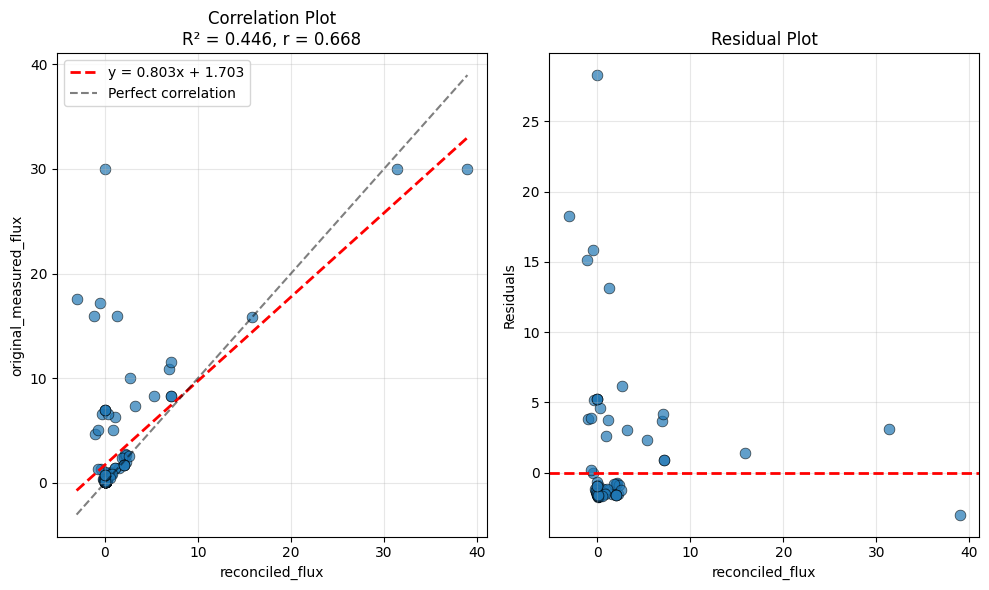

METABOLIC FLUX ANALYSIS REPORT
Comparing: reconciled_flux vs original_measured_flux

STATISTICAL SUMMARY:
--------------------
total_reactions: 2712
reactions_with_both_values: 128
reactions_missing_method1: 0
reactions_missing_method2: 2584
mean_absolute_difference: 1.647202
median_absolute_difference: 0.143758
std_absolute_difference: 4.300128
mean_relative_difference: 7818390.429116
median_relative_difference: 0.406407
max_absolute_difference: 30.000000
min_absolute_difference: 0.000000

CORRELATION ANALYSIS:
--------------------
pearson_r: 0.667762
pearson_p: 0.000000
spearman_r: 0.307787
spearman_p: 0.000409
r_squared: 0.445906
slope: 0.802916
intercept: 1.702637
n_points: 128

TOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:
--------------------------------------------------
NADH5: 0.000000 vs 30.000000 (diff: 30.000000)
CO2tpp: -3.046102 vs 17.520000 (diff: 20.566102)
GAPD: -0.487776 vs 17.150000 (diff: 17.637776)

TOP 3 REACTIONS WITH SMALLEST ABSOLUTE DIFFERENCES:
----------

'============================================================\nMETABOLIC FLUX ANALYSIS REPORT\n============================================================\nComparing: reconciled_flux vs original_measured_flux\n\nSTATISTICAL SUMMARY:\n--------------------\ntotal_reactions: 2712\nreactions_with_both_values: 128\nreactions_missing_method1: 0\nreactions_missing_method2: 2584\nmean_absolute_difference: 1.647202\nmedian_absolute_difference: 0.143758\nstd_absolute_difference: 4.300128\nmean_relative_difference: 7818390.429116\nmedian_relative_difference: 0.406407\nmax_absolute_difference: 30.000000\nmin_absolute_difference: 0.000000\n\nCORRELATION ANALYSIS:\n--------------------\npearson_r: 0.667762\npearson_p: 0.000000\nspearman_r: 0.307787\nspearman_p: 0.000409\nr_squared: 0.445906\nslope: 0.802916\nintercept: 1.702637\nn_points: 128\n\nTOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:\n--------------------------------------------------\nNADH5: 0.000000 vs 30.000000 (diff: 30.000000)\nCO2

In [52]:
from scripts.flux_analysis_module import FluxAnalyzer

analyzer = FluxAnalyzer(recon_iml1515_results, 'reconciled_flux', 'original_measured_flux', 'rxn_id')
analyzer.correlation_analysis()
analyzer.generate_report()

## FBA vs Original experimental

In [75]:
from scripts.ECOMICS_analysis import apply_ecomics_condition

modified_model = apply_ecomics_condition("MD121", "none")

results_fba = iML1515_model.optimize()
print(f'Original model biomass: {iML1515_model.objective.value}')

results_fba_modified = modified_model.optimize()
print(f'Modified model biomass: {modified_model.objective.value}')

df_fluxes = pd.DataFrame({
        "rxn_id": results_fba.fluxes.index,
        "FBA":    results_fba.fluxes.values,
    })

df_fluxes_modified = pd.DataFrame({
        "rxn_id": results_fba_modified.fluxes.index,
        "FBA":    results_fba_modified.fluxes.values,
    })


Applying M9+Glu medium
Set EX_glc__D_e lower bound to -10
Set EX_nh4_e lower bound to -5.01
Set EX_so4_e lower bound to -1.7
Set EX_o2_e lower bound to -15.86
Set EX_co2_e lower bound to 17.52
Original model biomass: 0.8769972144269629
Modified model biomass: 0.46389253989498735


In [76]:
FBA_iml1515_results = pd.merge(exp_fluxes_df, df_fluxes, on='rxn_id', how='left')
FBA_iml1515_results_modified = pd.merge(exp_fluxes_df, df_fluxes_modified, on='rxn_id', how='left')

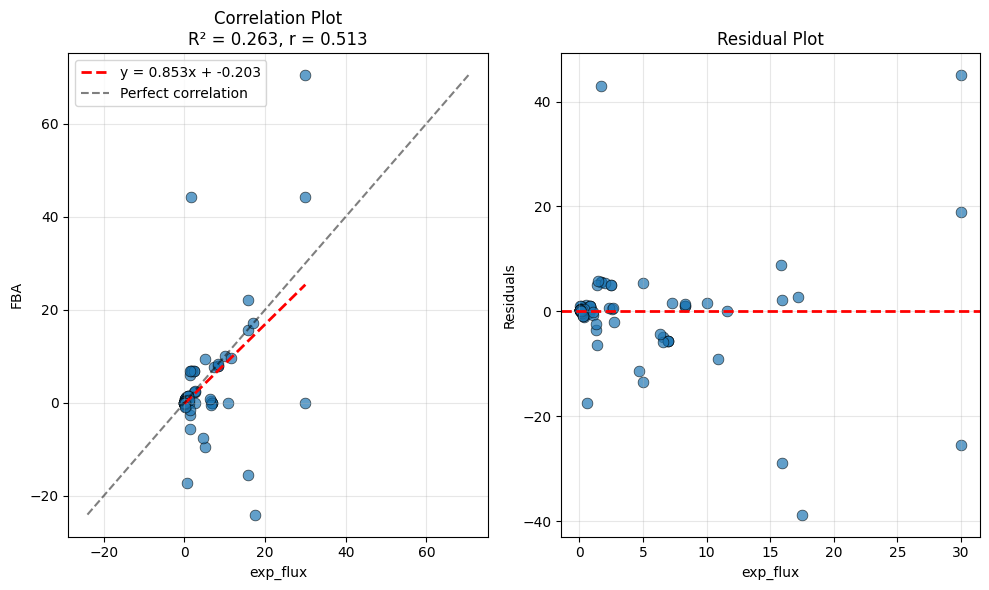

METABOLIC FLUX ANALYSIS REPORT
Comparing: exp_flux vs FBA

STATISTICAL SUMMARY:
--------------------
total_reactions: 128
reactions_with_both_values: 128
reactions_missing_method1: 0
reactions_missing_method2: 0
mean_absolute_difference: 2.978982
median_absolute_difference: 0.204240
std_absolute_difference: 7.686788
mean_relative_difference: 1.575173
median_relative_difference: 0.859661
max_absolute_difference: 42.534290
min_absolute_difference: 0.000000

CORRELATION ANALYSIS:
--------------------
pearson_r: 0.512899
pearson_p: 0.000000
spearman_r: 0.314596
spearman_p: 0.000298
r_squared: 0.263065
slope: 0.853437
intercept: -0.202651
n_points: 128

TOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:
--------------------------------------------------
SUCDi: 1.720000 vs 44.254290 (diff: 42.534290)
CO2tpp: 17.520000 vs -24.003293 (diff: 41.523293)
ATPS4rpp: 30.000000 vs 70.432494 (diff: 40.432494)

TOP 3 REACTIONS WITH SMALLEST ABSOLUTE DIFFERENCES:
----------------------------------------

'============================================================\nMETABOLIC FLUX ANALYSIS REPORT\n============================================================\nComparing: exp_flux vs FBA\n\nSTATISTICAL SUMMARY:\n--------------------\ntotal_reactions: 128\nreactions_with_both_values: 128\nreactions_missing_method1: 0\nreactions_missing_method2: 0\nmean_absolute_difference: 2.978982\nmedian_absolute_difference: 0.204240\nstd_absolute_difference: 7.686788\nmean_relative_difference: 1.575173\nmedian_relative_difference: 0.859661\nmax_absolute_difference: 42.534290\nmin_absolute_difference: 0.000000\n\nCORRELATION ANALYSIS:\n--------------------\npearson_r: 0.512899\npearson_p: 0.000000\nspearman_r: 0.314596\nspearman_p: 0.000298\nr_squared: 0.263065\nslope: 0.853437\nintercept: -0.202651\nn_points: 128\n\nTOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:\n--------------------------------------------------\nSUCDi: 1.720000 vs 44.254290 (diff: 42.534290)\nCO2tpp: 17.520000 vs -24.003293 (diff:

In [78]:
analyzer = FluxAnalyzer(FBA_iml1515_results, 'exp_flux', 'FBA', 'rxn_id')
analyzer.correlation_analysis()
analyzer.generate_report()

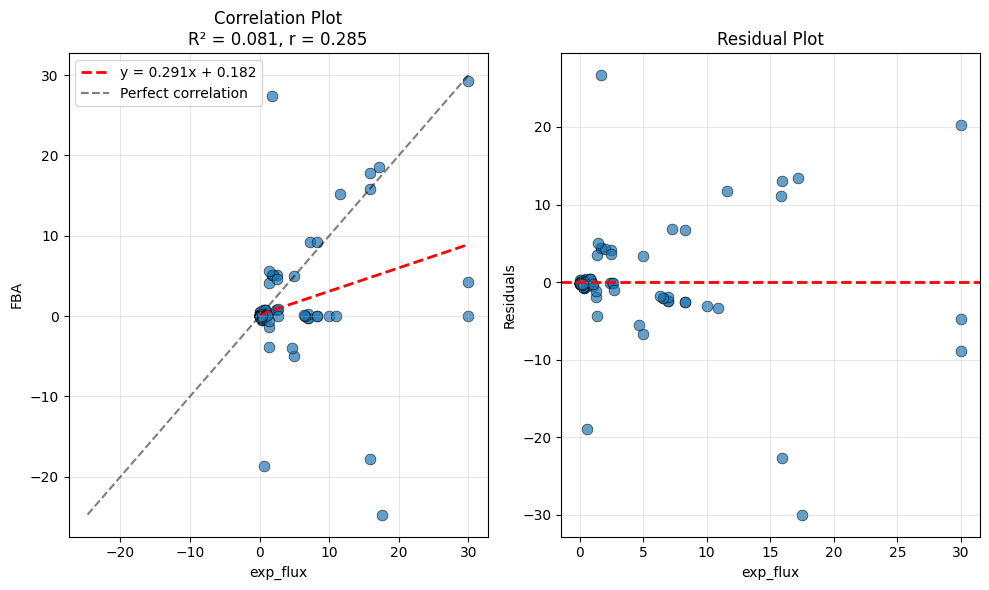

METABOLIC FLUX ANALYSIS REPORT
Comparing: exp_flux vs FBA

STATISTICAL SUMMARY:
--------------------
total_reactions: 128
reactions_with_both_values: 128
reactions_missing_method1: 0
reactions_missing_method2: 0
mean_absolute_difference: 2.632397
median_absolute_difference: 0.116577
std_absolute_difference: 6.633106
mean_relative_difference: 1.176415
median_relative_difference: 0.359987
max_absolute_difference: 42.226370
min_absolute_difference: 0.000000

CORRELATION ANALYSIS:
--------------------
pearson_r: 0.284901
pearson_p: 0.001116
spearman_r: 0.205781
spearman_p: 0.019790
r_squared: 0.081168
slope: 0.291314
intercept: 0.182486
n_points: 128

TOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:
--------------------------------------------------
CO2tpp: 17.520000 vs -24.706370 (diff: 42.226370)
PGM: 15.900000 vs -17.819101 (diff: 33.719101)
CYTBO3_4pp: 30.000000 vs 0.000000 (diff: 30.000000)

TOP 3 REACTIONS WITH SMALLEST ABSOLUTE DIFFERENCES:
----------------------------------------

'============================================================\nMETABOLIC FLUX ANALYSIS REPORT\n============================================================\nComparing: exp_flux vs FBA\n\nSTATISTICAL SUMMARY:\n--------------------\ntotal_reactions: 128\nreactions_with_both_values: 128\nreactions_missing_method1: 0\nreactions_missing_method2: 0\nmean_absolute_difference: 2.632397\nmedian_absolute_difference: 0.116577\nstd_absolute_difference: 6.633106\nmean_relative_difference: 1.176415\nmedian_relative_difference: 0.359987\nmax_absolute_difference: 42.226370\nmin_absolute_difference: 0.000000\n\nCORRELATION ANALYSIS:\n--------------------\npearson_r: 0.284901\npearson_p: 0.001116\nspearman_r: 0.205781\nspearman_p: 0.019790\nr_squared: 0.081168\nslope: 0.291314\nintercept: 0.182486\nn_points: 128\n\nTOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:\n--------------------------------------------------\nCO2tpp: 17.520000 vs -24.706370 (diff: 42.226370)\nPGM: 15.900000 vs -17.819101 (diff: 

In [77]:
analyzer = FluxAnalyzer(FBA_iml1515_results_modified, 'exp_flux', 'FBA', 'rxn_id')
analyzer.correlation_analysis()
analyzer.generate_report()

## Reconciliation simple optimality

In [44]:
FBA_iml1515_results3 = pd.merge(exp_fluxes_df, recon_iml1515_results_3, on='rxn_id', how='left')

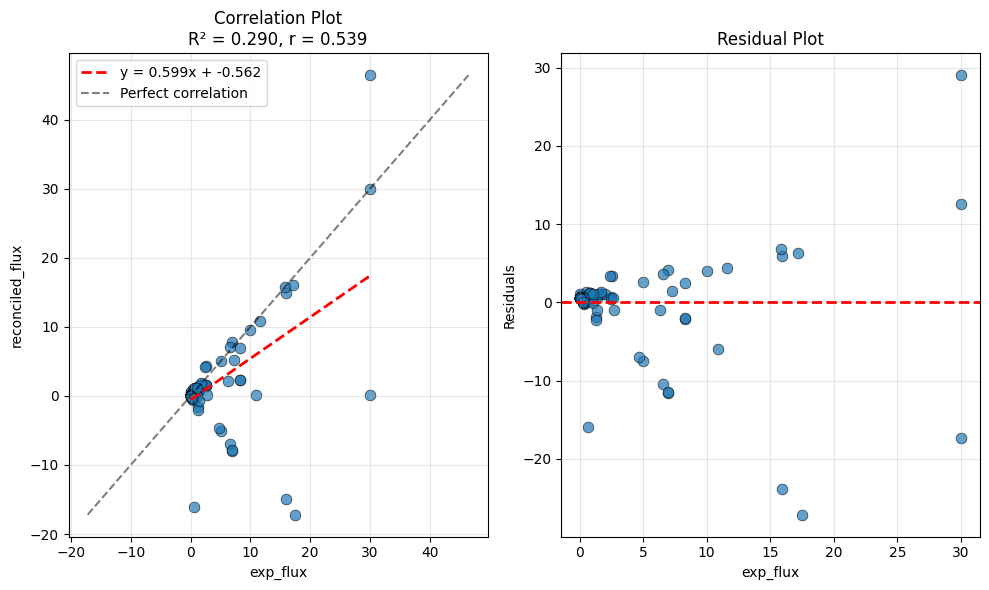

METABOLIC FLUX ANALYSIS REPORT
Comparing: exp_flux vs reconciled_flux

STATISTICAL SUMMARY:
--------------------
total_reactions: 128
reactions_with_both_values: 128
reactions_missing_method1: 0
reactions_missing_method2: 0
mean_absolute_difference: 2.024576
median_absolute_difference: 0.108311
std_absolute_difference: 5.712383
mean_relative_difference: 0.927739
median_relative_difference: 0.350920
max_absolute_difference: 34.707909
min_absolute_difference: 0.001831

CORRELATION ANALYSIS:
--------------------
pearson_r: 0.538701
pearson_p: 0.000000
spearman_r: 0.381125
spearman_p: 0.000009
r_squared: 0.290199
slope: 0.598690
intercept: -0.562400
n_points: 128

TOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:
--------------------------------------------------
CO2tpp: 17.520000 vs -17.187909 (diff: 34.707909)
PGM: 15.900000 vs -14.901624 (diff: 30.801624)
NADH5: 30.000000 vs 0.125353 (diff: 29.874647)

TOP 3 REACTIONS WITH SMALLEST ABSOLUTE DIFFERENCES:
--------------------------------

'============================================================\nMETABOLIC FLUX ANALYSIS REPORT\n============================================================\nComparing: exp_flux vs reconciled_flux\n\nSTATISTICAL SUMMARY:\n--------------------\ntotal_reactions: 128\nreactions_with_both_values: 128\nreactions_missing_method1: 0\nreactions_missing_method2: 0\nmean_absolute_difference: 2.024576\nmedian_absolute_difference: 0.108311\nstd_absolute_difference: 5.712383\nmean_relative_difference: 0.927739\nmedian_relative_difference: 0.350920\nmax_absolute_difference: 34.707909\nmin_absolute_difference: 0.001831\n\nCORRELATION ANALYSIS:\n--------------------\npearson_r: 0.538701\npearson_p: 0.000000\nspearman_r: 0.381125\nspearman_p: 0.000009\nr_squared: 0.290199\nslope: 0.598690\nintercept: -0.562400\nn_points: 128\n\nTOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:\n--------------------------------------------------\nCO2tpp: 17.520000 vs -17.187909 (diff: 34.707909)\nPGM: 15.900000 vs -14.9

In [46]:
analyzer = FluxAnalyzer(FBA_iml1515_results3, 'exp_flux', 'reconciled_flux', 'rxn_id')

analyzer.correlation_analysis()
analyzer.generate_report()

## Reconciliation with just exchanges

In [48]:
FBA_iml1515_results_exchanges_ = pd.merge(exp_fluxes_df, recon_iml1515_results, on='rxn_id', how='left')

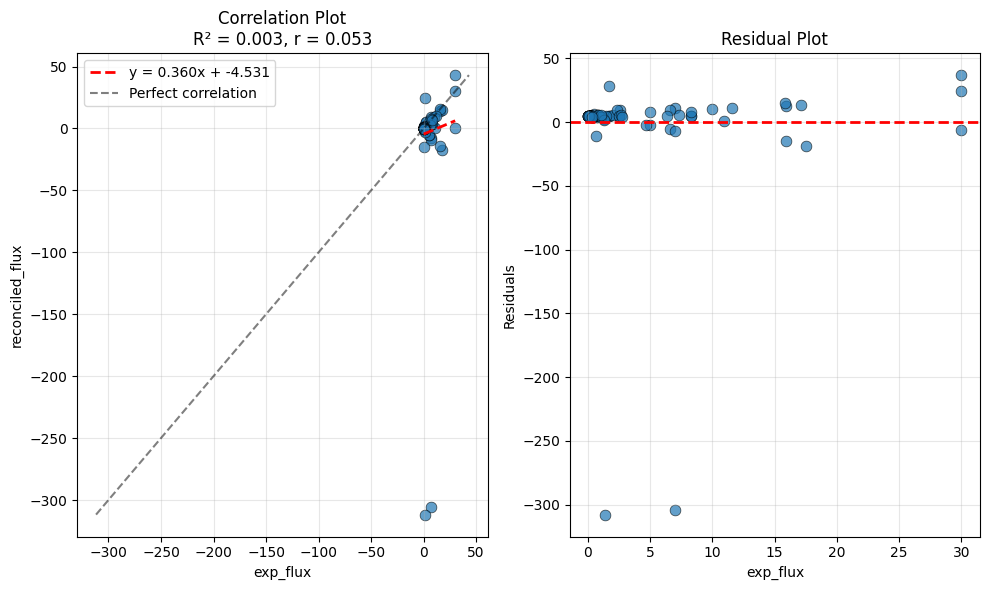

METABOLIC FLUX ANALYSIS REPORT
Comparing: exp_flux vs reconciled_flux

STATISTICAL SUMMARY:
--------------------
total_reactions: 128
reactions_with_both_values: 128
reactions_missing_method1: 0
reactions_missing_method2: 0
mean_absolute_difference: 7.040326
median_absolute_difference: 0.144218
std_absolute_difference: 39.135164
mean_relative_difference: 3.196942
median_relative_difference: 0.503818
max_absolute_difference: 313.164227
min_absolute_difference: 0.001481

CORRELATION ANALYSIS:
--------------------
pearson_r: 0.052645
pearson_p: 0.555073
spearman_r: 0.326691
spearman_p: 0.000167
r_squared: 0.002771
slope: 0.359787
intercept: -4.530522
n_points: 128

TOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:
--------------------------------------------------
SUCOAS: 1.380000 vs -311.784227 (diff: 313.164227)
ACt2rpp: 6.960000 vs -305.957001 (diff: 312.917001)
CO2tpp: 17.520000 vs -17.200346 (diff: 34.720346)

TOP 3 REACTIONS WITH SMALLEST ABSOLUTE DIFFERENCES:
---------------------

'============================================================\nMETABOLIC FLUX ANALYSIS REPORT\n============================================================\nComparing: exp_flux vs reconciled_flux\n\nSTATISTICAL SUMMARY:\n--------------------\ntotal_reactions: 128\nreactions_with_both_values: 128\nreactions_missing_method1: 0\nreactions_missing_method2: 0\nmean_absolute_difference: 7.040326\nmedian_absolute_difference: 0.144218\nstd_absolute_difference: 39.135164\nmean_relative_difference: 3.196942\nmedian_relative_difference: 0.503818\nmax_absolute_difference: 313.164227\nmin_absolute_difference: 0.001481\n\nCORRELATION ANALYSIS:\n--------------------\npearson_r: 0.052645\npearson_p: 0.555073\nspearman_r: 0.326691\nspearman_p: 0.000167\nr_squared: 0.002771\nslope: 0.359787\nintercept: -4.530522\nn_points: 128\n\nTOP 3 REACTIONS WITH BIGGEST ABSOLUTE DIFFERENCES:\n--------------------------------------------------\nSUCOAS: 1.380000 vs -311.784227 (diff: 313.164227)\nACt2rpp: 6.960000 vs

In [49]:
analyzer = FluxAnalyzer(FBA_iml1515_results_exchanges_, 'exp_flux', 'reconciled_flux', 'rxn_id')

analyzer.correlation_analysis()
analyzer.generate_report()

## Takeaways
- So far the best fitting model is the original one
- Reconciling with just exchanges gives a terrible R2 (0.003), bc it's just 5 datapoints
- Optimality constraints not reaching feasible solutions - created a ''
- Simple optimality works but bad correlation (R2=0.29)

next steps:
- Compare reconciled fluxes (results 0f 0.44 in the csv) to FBA. Discard Biomass. 
- Add to OG recon, that uses just exchnages, the simple dual optimization to add the biomass maximization and consider some sort of weights. 
- Run and compare the correlation (should be higher than the best result so far 0.44, and the biomass result should be better too).
- Compare NEW reconciled fluxes to FBA